# Pipeline para identificação de padrões gerais da escrita científica

Este notebook analisa o texto completo dos artigos, sem separar por seção. O foco é identificar padrões gerais de escrita, especialmente estruturas retóricas, conectores discursivos, marcadores de argumentação e perfis de estilo por artigo.

A abordagem principal é baseada em regras linguísticas interpretáveis. Clustering é usado apenas para agrupar perfis gerais de escrita dos artigos, não para inferir temas de pesquisa.

In [ ]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, cohen_kappa_score

from IPython.display import display
from google.colab import drive

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)


In [ ]:
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
CAMINHO_CSV = "/content/drive/MyDrive/ARTIGOS SELECIONADOS/textos_pdfs.csv"
COLUNA_TEXTO = "texto"
COLUNA_ID = "arquivo"

df = pd.read_csv(CAMINHO_CSV)

colunas = [COLUNA_TEXTO]
if COLUNA_ID in df.columns:
    colunas = [COLUNA_ID, COLUNA_TEXTO]

df = df[colunas].dropna(subset=[COLUNA_TEXTO]).reset_index(drop=True)

if COLUNA_ID not in df.columns:
    df[COLUNA_ID] = [f"doc_{i}" for i in range(len(df))]

print(df.shape)
display(df.head(2))


(800, 2)


,arquivo,texto
0,/content/drive/MyDrive/ARTIGOS SELECIONADOS/3 - ACM Transactions on Graphics/DEZ_2024/3687992.pdf,.\n.\nLatest updates: hps://dl.acm.org/doi/10.1145/3687992\n.\n.\nRESEARCH-ARTICLE\nA Progressive Embedding Approac...
1,/content/drive/MyDrive/ARTIGOS SELECIONADOS/3 - ACM Transactions on Graphics/DEZ_2024/3687915.pdf,.\n.\nLatest updates: hps://dl.acm.org/doi/10.1145/3687915\n.\n.\nRESEARCH-ARTICLE\nStripe Embedding: Eﬀicient Maps...


In [ ]:
SAIDA_DIR = "/content/drive/MyDrive/ARTIGOS SELECIONADOS/resultados_padroes_gerais_escrita"
RANDOM_STATE = 42

Path(SAIDA_DIR).mkdir(parents=True, exist_ok=True)


## 1. Preparação do texto completo

Esta etapa remove referências, metadados editoriais e fragmentos muito ruidosos. A unidade de análise passa a ser a sentença no texto completo.

In [ ]:
PADROES_RUIDO_SENTENCA = [
    r"\bdoi\b",
    r"\bisbn\b",
    r"\bissn\b",
    r"\bcopyright\b",
    r"\bpermission\b",
    r"\bacm reference format\b",
    r"\bproceedings of\b",
    r"\bpublicationdate\b",
    r"\btransactions on\b",
    r"\bvol\.?\s*\d+\b",
    r"\bno\.?\s*\d+\b",
    r"\bpp\.?\s*\d+",
    r"\barxiv\b",
    r"\bpreprint\b",
    r"\bretrieved from\b",
    r"\bavailable at\b"
]

def normalizar_texto(texto):
    texto = str(texto)
    texto = texto.replace("\u00ad", "")
    texto = re.sub(r"(?<=[a-z])-[ \n\r\t]+(?=[a-z])", "", texto)
    texto = re.sub(r"[\n\r\t]+", " ", texto)
    texto = re.sub(r"\s+", " ", texto)
    return texto.strip()

def remover_referencias(texto):
    texto = normalizar_texto(texto)
    candidatos = list(re.finditer(r"\b(references|bibliography|acknowledg(e)?ments)\b", texto, flags=re.I))
    if not candidatos:
        return texto
    limite_minimo = int(len(texto) * 0.35)
    candidatos = [m for m in candidatos if m.start() >= limite_minimo]
    if candidatos:
        return texto[:candidatos[0].start()].strip()
    return texto

def segmentar_sentencas(texto):
    texto = remover_referencias(texto)
    texto = re.sub(r"\s+", " ", texto)
    partes = re.split(r"(?<=[.!?])\s+(?=[A-Z0-9(])", texto)
    return [p.strip() for p in partes if p.strip()]

def sentenca_valida(s):
    s = str(s).strip()
    palavras = re.findall(r"\b[A-Za-z][A-Za-z\-']*\b", s)
    if len(palavras) < 6 or len(palavras) > 90:
        return False
    if len(s) < 35 or len(s) > 700:
        return False
    minuscula = s.lower()
    if any(re.search(p, minuscula, flags=re.I) for p in PADROES_RUIDO_SENTENCA):
        return False
    if sum(ch.isdigit() for ch in s) > max(12, len(s) * 0.18):
        return False
    if len(set(palavras)) < 4:
        return False
    return True

def limpar_sentenca_modelo(s):
    s = str(s)
    s = re.sub(r"\[[^\]]{1,120}\]", " ", s)
    s = re.sub(r"\([A-Z][A-Za-z\-]+ et al\.?,?\s*\d{4}[a-z]?\)", " ", s)
    s = re.sub(r"\((?:Fig|Figure|Table|Eq)\.?\s*\d+[A-Za-z]?\)", " ", s, flags=re.I)
    s = re.sub(r"\b(?:Fig|Figure|Table)\.?\s*\d+[A-Za-z]?\b", " ", s, flags=re.I)
    s = re.sub(r"https?://\S+|www\.\S+|\S+@\S+", " ", s)
    s = re.sub(r"[^A-Za-z0-9%.,;:!?()' \-]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


## 2. Dicionários de padrões retóricos e conectores

Os padrões são detectados por marcadores linguísticos. O objetivo não é identificar o tema do artigo, mas como o texto argumenta, apresenta objetivos, descreve métodos, relata resultados e conecta ideias.

In [ ]:
PADROES_RETÓRICOS = {
    "contextualizacao": [
        r"\bin recent years\b", r"\brecently\b", r"\bhas become\b", r"\bhave become\b",
        r"\bplays? an important role\b", r"\bis widely used\b", r"\bare widely used\b",
        r"\bthere has been\b", r"\bthe increasing\b", r"\bthe growth of\b",
        r"\bwith the advent of\b", r"\bthe emergence of\b", r"\bbackground\b"
    ],
    "lacuna_problema": [
        r"\bhowever\b", r"\bnevertheless\b", r"\bnonetheless\b", r"\bdespite\b",
        r"\balthough\b", r"\bchallenge(s)?\b", r"\bproblem(s)?\b", r"\bissue(s)?\b",
        r"\blimitation(s)?\b", r"\blimited\b", r"\black(s|ing)?\b", r"\bthere is a lack of\b",
        r"\bremains?\b", r"\bnot well understood\b", r"\bopen question\b", r"\bdifficult to\b"
    ],
    "objetivo_contribuicao": [
        r"\bwe propose\b", r"\bthis paper proposes\b", r"\bwe present\b", r"\bthis paper presents\b",
        r"\bwe introduce\b", r"\bthis work introduces\b", r"\bwe aim to\b", r"\bthis paper aims\b",
        r"\bour goal is\b", r"\bthe goal of this\b", r"\bwe contribute\b", r"\bour contribution(s)?\b",
        r"\bthe main contribution\b", r"\bwe investigate\b", r"\bwe study\b", r"\bwe explore\b"
    ],
    "metodo_procedimento": [
        r"\bwe use\b", r"\bwe used\b", r"\bwe employ\b", r"\bwe employed\b", r"\bwe apply\b",
        r"\bwe applied\b", r"\bwe conduct\b", r"\bwe conducted\b", r"\bwe evaluate\b",
        r"\bwe evaluated\b", r"\bwe train\b", r"\bwe trained\b", r"\bwe implement\b",
        r"\bwe implemented\b", r"\bmethod\b", r"\bmethodology\b", r"\bapproach\b",
        r"\bframework\b", r"\balgorithm\b", r"\bexperiment(s)?\b", r"\bdataset\b"
    ],
    "resultado_achado": [
        r"\bresults show\b", r"\bour results show\b", r"\bthe results show\b", r"\bwe find\b",
        r"\bwe found\b", r"\bwe observe\b", r"\bwe observed\b", r"\bour findings\b",
        r"\bthe findings\b", r"\bachieve(s|d)?\b", r"\boutperform(s|ed)?\b", r"\bimprove(s|d|ment)?\b",
        r"\breduce(s|d)?\b", r"\bincrease(s|d)?\b", r"\bdemonstrate(s|d)?\b", r"\bshow(s|ed)? that\b"
    ],
    "implicacao_conclusao": [
        r"\btherefore\b", r"\bthus\b", r"\bhence\b", r"\bconsequently\b", r"\bin conclusion\b",
        r"\bto conclude\b", r"\bwe conclude\b", r"\bthis suggests\b", r"\bthese findings suggest\b",
        r"\bthis indicates\b", r"\bthese results indicate\b", r"\bimplication(s)?\b", r"\bpractical implication(s)?\b"
    ],
    "limitacao_futuro": [
        r"\bfuture work\b", r"\bin future work\b", r"\bfuture research\b", r"\bfurther research\b",
        r"\bwe plan to\b", r"\bwe intend to\b", r"\blimitation(s)?\b", r"\bone limitation\b",
        r"\bthis study is limited\b", r"\bwe did not\b", r"\bwe leave\b", r"\bremains for future\b"
    ]
}

CONECTORES = {
    "adicao": [
        r"\bin addition\b", r"\bfurthermore\b", r"\bmoreover\b", r"\balso\b", r"\badditionally\b",
        r"\bbesides\b", r"\bas well as\b", r"\bnot only\b"
    ],
    "contraste": [
        r"\bhowever\b", r"\bnevertheless\b", r"\bnonetheless\b", r"\bbut\b", r"\byet\b",
        r"\balthough\b", r"\bwhile\b", r"\bwhereas\b", r"\bin contrast\b", r"\bon the other hand\b"
    ],
    "causa_efeito": [
        r"\bbecause\b", r"\bsince\b", r"\bdue to\b", r"\bas a result\b", r"\btherefore\b",
        r"\bthus\b", r"\bhence\b", r"\bconsequently\b", r"\baccordingly\b", r"\bleads? to\b"
    ],
    "sequencia": [
        r"\bfirst\b", r"\bsecond\b", r"\bthird\b", r"\bfinally\b", r"\bthen\b", r"\bnext\b",
        r"\bsubsequently\b", r"\bafterward(s)?\b", r"\bprior to\b", r"\bfollowing\b"
    ],
    "exemplo": [
        r"\bfor example\b", r"\bfor instance\b", r"\bsuch as\b", r"\be\.g\.\b", r"\bincluding\b"
    ],
    "comparacao": [
        r"\bsimilarly\b", r"\blikewise\b", r"\bcompared with\b", r"\bcompared to\b",
        r"\bin comparison\b", r"\brelative to\b"
    ],
    "condicao": [
        r"\bif\b", r"\bwhen\b", r"\bunless\b", r"\bprovided that\b", r"\bin case\b", r"\bdepending on\b"
    ],
    "enfase": [
        r"\bparticularly\b", r"\bespecially\b", r"\bnotably\b", r"\bsignificantly\b", r"\bimportantly\b"
    ]
}

ORDEM_PADROES = [
    "objetivo_contribuicao",
    "resultado_achado",
    "limitacao_futuro",
    "lacuna_problema",
    "metodo_procedimento",
    "implicacao_conclusao",
    "contextualizacao"
]


In [ ]:
def contar_padroes(s, dicionario):
    s = str(s).lower()
    saida = {}
    for nome, padroes in dicionario.items():
        total = 0
        for padrao in padroes:
            total += len(re.findall(padrao, s, flags=re.I))
        saida[nome] = total
    return saida

def escolher_padrao_retorico(scores):
    positivos = {k: v for k, v in scores.items() if v > 0}
    if not positivos:
        return "sem_marcador_explicito"
    maior = max(positivos.values())
    candidatos = [k for k, v in positivos.items() if v == maior]
    candidatos = sorted(candidatos, key=lambda x: ORDEM_PADROES.index(x) if x in ORDEM_PADROES else 999)
    return candidatos[0]

def escolher_conector(scores):
    positivos = {k: v for k, v in scores.items() if v > 0}
    if not positivos:
        return "sem_conector"
    maior = max(positivos.values())
    candidatos = [k for k, v in positivos.items() if v == maior]
    return sorted(candidatos)[0]

def extrair_recursos_sentenca(sentenca):
    s = str(sentenca)
    tokens = re.findall(r"\b[A-Za-z][A-Za-z\-']*\b", s)
    lower = s.lower()
    scores_ret = contar_padroes(lower, PADROES_RETÓRICOS)
    scores_con = contar_padroes(lower, CONECTORES)
    recursos = {
        "n_palavras": len(tokens),
        "n_caracteres": len(s),
        "padrao_retorico": escolher_padrao_retorico(scores_ret),
        "conector_principal": escolher_conector(scores_con),
        "n_conectores": sum(scores_con.values()),
        "n_marcadores_retoricos": sum(scores_ret.values()),
        "tem_citacao": int(bool(re.search(r"\([A-Z][A-Za-z\-]+ et al\.?,?\s*\d{4}[a-z]?\)|\[[0-9,;\s\-]+\]", s))),
        "tem_primeira_pessoa": int(bool(re.search(r"\b(we|our|ours|us)\b", lower))),
        "tem_modalizacao": int(bool(re.search(r"\b(may|might|can|could|should|would|likely|possibly|potentially|suggests?)\b", lower))),
        "voz_passiva_aprox": int(bool(re.search(r"\b(is|are|was|were|be|been|being)\s+[a-z]+ed\b", lower))),
    }
    for k, v in scores_ret.items():
        recursos[f"ret_{k}"] = v
    for k, v in scores_con.items():
        recursos[f"con_{k}"] = v
    return recursos


## 3. Geração da base de sentenças do texto completo

In [ ]:
registros = []

for _, row in df.iterrows():
    doc_id = row[COLUNA_ID]
    texto = row[COLUNA_TEXTO]
    sentencas = segmentar_sentencas(texto)
    sentencas = [s for s in sentencas if sentenca_valida(s)]
    total = len(sentencas)
    for i, sent in enumerate(sentencas, start=1):
        sent_limpa = limpar_sentenca_modelo(sent)
        if not sentenca_valida(sent_limpa):
            continue
        recursos = extrair_recursos_sentenca(sent_limpa)
        registro = {
            COLUNA_ID: doc_id,
            "ordem_sentenca": i,
            "n_sentencas_artigo": total,
            "posicao_relativa": i / total if total else np.nan,
            "sentenca_original": sent,
            "sentenca_modelo": sent_limpa
        }
        registro.update(recursos)
        registros.append(registro)

df_sent = pd.DataFrame(registros).reset_index(drop=True)

print(df_sent.shape)
display(df_sent.head(10))


(232355, 31)


,arquivo,ordem_sentenca,n_sentencas_artigo,posicao_relativa,sentenca_original,sentenca_modelo,n_palavras,n_caracteres,padrao_retorico,conector_principal,n_conectores,n_marcadores_retoricos,tem_citacao,tem_primeira_pessoa,tem_modalizacao,voz_passiva_aprox,ret_contextualizacao,ret_lacuna_problema,ret_objetivo_contribuicao,ret_metodo_procedimento,ret_resultado_achado,ret_implicacao_conclusao,ret_limitacao_futuro,con_adicao,con_contraste,con_causa_efeito,con_sequencia,con_exemplo,con_comparacao,con_condicao,con_enfase
0,/content/drive/MyDrive/ARTIGOS SELECIONADOS/3 - ACM Transactions on Graphics/DEZ_2024/3687992.pdf,1,503,0.001988,RESEARCH-ARTICLE A Progressive Embedding Approach to Bijective Tetrahedral Maps driven by Cluster Mesh Topology VALE...,RESEARCH-ARTICLE A Progressive Embedding Approach to Bijective Tetrahedral Maps driven by Cluster Mesh Topology VALE...,24,180,metodo_procedimento,sem_conector,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
1,/content/drive/MyDrive/ARTIGOS SELECIONADOS/3 - ACM Transactions on Graphics/DEZ_2024/3687992.pdf,2,503,0.003976,"MARCEL CAMPEN, Osnabrück University, Osnabruck, Niedersachsen, Germany .","MARCEL CAMPEN, Osnabr ck University, Osnabruck, Niedersachsen, Germany .",8,72,sem_marcador_explicito,sem_conector,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,/content/drive/MyDrive/ARTIGOS SELECIONADOS/3 - ACM Transactions on Graphics/DEZ_2024/3687992.pdf,3,503,0.005964,"DAVID BOMMES, University of Bern, Bern, BE, Switzerland . . .","DAVID BOMMES, University of Bern, Bern, BE, Switzerland . . .",8,61,sem_marcador_explicito,sem_conector,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,/content/drive/MyDrive/ARTIGOS SELECIONADOS/3 - ACM Transactions on Graphics/DEZ_2024/3687992.pdf,4,503,0.007952,A Progressive Embedding Approach to Bijective Tetrahedral Maps driven by Cluster Mesh Topology VALENTIN Z.,A Progressive Embedding Approach to Bijective Tetrahedral Maps driven by Cluster Mesh Topology VALENTIN Z.,15,106,metodo_procedimento,sem_conector,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
4,/content/drive/MyDrive/ARTIGOS SELECIONADOS/3 - ACM Transactions on Graphics/DEZ_2024/3687992.pdf,5,503,0.009940,"NIGOLIAN, University of Bern, Switzerland MARCEL CAMPEN, Osnabrück University, Germany DAVID BOMMES, University of B...","NIGOLIAN, University of Bern, Switzerland MARCEL CAMPEN, Osnabr ck University, Germany DAVID BOMMES, University of B...",18,137,sem_marcador_explicito,sem_conector,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,/content/drive/MyDrive/ARTIGOS SELECIONADOS/3 - ACM Transactions on Graphics/DEZ_2024/3687992.pdf,6,503,0.011928,"Given a ball-topology tetrahedral mesh (left) and star-shaped boundary constraints, we generate a bijective piecewis...","Given a ball-topology tetrahedral mesh (left) and star-shaped boundary constraints, we generate a bijective piecewis...",21,154,sem_marcador_explicito,sem_conector,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,/content/drive/MyDrive/ARTIGOS SELECIONADOS/3 - ACM Transactions on Graphics/DEZ_2024/3687992.pdf,7,503,0.013917,"We improve the recent Shrink-and-Expand approach [Nigolian et al .2023], which relies on a two-step process.","We improve the recent Shrink-and-Expand approach , which relies on a two-step process.",12,86,resultado_achado,sem_conector,0,2,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0
7,/content/drive/MyDrive/ARTIGOS SELECIONADOS/3 - ACM Transactions on Graphics/DEZ_2024/3687992.pdf,8,503,0.015905,"During the first shrinkage step, all interior vertices are clustered to a single focal point, degenerating most tetr...","During the first shrinkage step, all interior vertices are clustered to a single focal point, degenerating most tetr...",19,133,sem_marcador_explicito,sequencia,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
8,/content/drive/MyDrive/ARTIGOS SELECIONADOS/3 - ACM Transactions on Graphics/DEZ_2024/3687992.pdf,9,503,0.017893,"In the second expansion step, interior vertices (blue) are successively detached from the cluster while ensuring tha..."

## 4. Padrões retóricos gerais

,padrao_retorico,n_sentencas,percentual
0,sem_marcador_explicito,158312,68.133675
1,metodo_procedimento,23788,10.237783
2,lacuna_problema,21528,9.265133
3,resultado_achado,14809,6.373437
4,implicacao_conclusao,7144,3.074606
5,objetivo_contribuicao,3086,1.328140
6,contextualizacao,1875,0.806955
7,limitacao_futuro,1813,0.780272


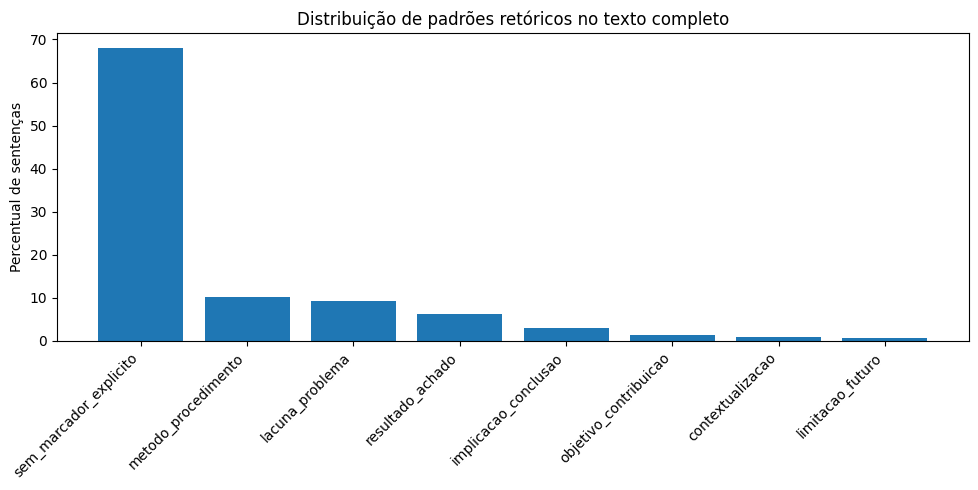

In [ ]:
resumo_padroes = (
    df_sent["padrao_retorico"]
    .value_counts(dropna=False)
    .rename_axis("padrao_retorico")
    .reset_index(name="n_sentencas")
)

resumo_padroes["percentual"] = 100 * resumo_padroes["n_sentencas"] / resumo_padroes["n_sentencas"].sum()

display(resumo_padroes)

plt.figure(figsize=(10, 5))
plt.bar(resumo_padroes["padrao_retorico"], resumo_padroes["percentual"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Percentual de sentenças")
plt.title("Distribuição de padrões retóricos no texto completo")
plt.tight_layout()
plt.show()


## 5. Conectores mais utilizados

,tipo_conector,frequencia,por_1000_sentencas
0,contraste,24530,105.571216
1,sequencia,24100,103.720600
2,causa_efeito,20263,87.207075
3,adicao,19160,82.460029
4,condicao,13449,57.881259
5,exemplo,13183,56.736459
6,enfase,4009,17.253771
7,comparacao,3728,16.044415


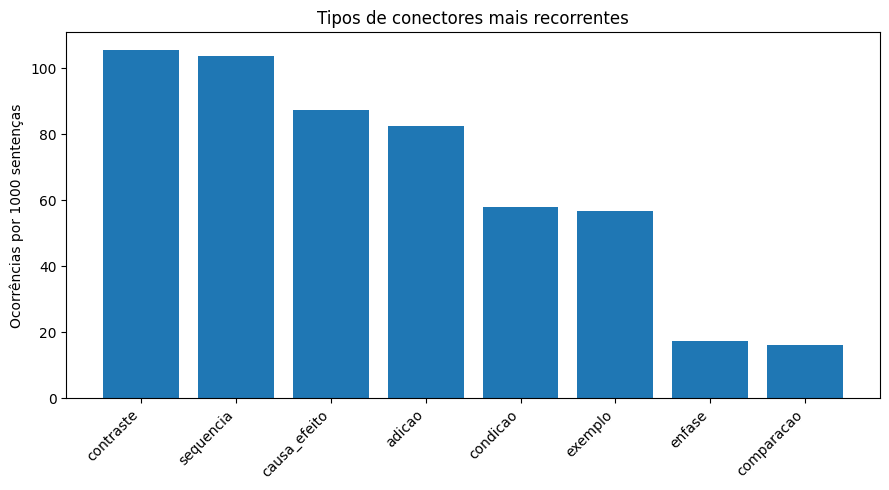

In [ ]:
colunas_conectores = [c for c in df_sent.columns if c.startswith("con_")]

ranking_conectores = (
    df_sent[colunas_conectores]
    .sum()
    .sort_values(ascending=False)
    .rename_axis("tipo_conector")
    .reset_index(name="frequencia")
)

ranking_conectores["tipo_conector"] = ranking_conectores["tipo_conector"].str.replace("con_", "", regex=False)
ranking_conectores["por_1000_sentencas"] = 1000 * ranking_conectores["frequencia"] / len(df_sent)

display(ranking_conectores)

plt.figure(figsize=(9, 5))
plt.bar(ranking_conectores["tipo_conector"], ranking_conectores["por_1000_sentencas"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Ocorrências por 1000 sentenças")
plt.title("Tipos de conectores mais recorrentes")
plt.tight_layout()
plt.show()


In [ ]:
conector_principal = (
    df_sent["conector_principal"]
    .value_counts(dropna=False)
    .rename_axis("conector_principal")
    .reset_index(name="n_sentencas")
)
conector_principal["percentual"] = 100 * conector_principal["n_sentencas"] / conector_principal["n_sentencas"].sum()

display(conector_principal)


,conector_principal,n_sentencas,percentual
0,sem_conector,141168,60.755310
1,causa_efeito,17375,7.477782
2,adicao,17087,7.353834
3,contraste,16817,7.237632
4,sequencia,16315,7.021583
5,condicao,9911,4.265456
6,exemplo,8482,3.650449
7,comparacao,2990,1.286824
8,enfase,2210,0.951131


## 6. Relação entre padrões retóricos e conectores

conector_principal,adicao,causa_efeito,comparacao,condicao,contraste,enfase,exemplo,sem_conector,sequencia
padrao_retorico,,,,,,,,,
contextualizacao,7.52,6.99,0.85,2.56,4.91,1.71,6.83,64.37,4.27
implicacao_conclusao,5.52,87.04,0.06,0.56,0.52,0.11,0.35,4.70,1.15
lacuna_problema,7.89,11.45,1.00,5.30,35.86,0.72,2.68,31.55,3.54
limitacao_futuro,10.37,10.37,0.55,3.14,7.39,0.77,3.47,58.14,5.79
metodo_procedimento,6.81,5.82,1.58,3.54,4.21,0.78,3.04,65.35,8.88
objetivo_contribuicao,6.71,6.09,0.45,1.72,3.92,0.71,2.11,66.20,12.09
resultado_achado,10.32,8.60,3.63,5.25,9.22,3.00,3.46,51.65,4.88
sem_marcador_explicito,7.14,3.49,1.15,4.39,4.01,0.85,4.04,67.30,7.63


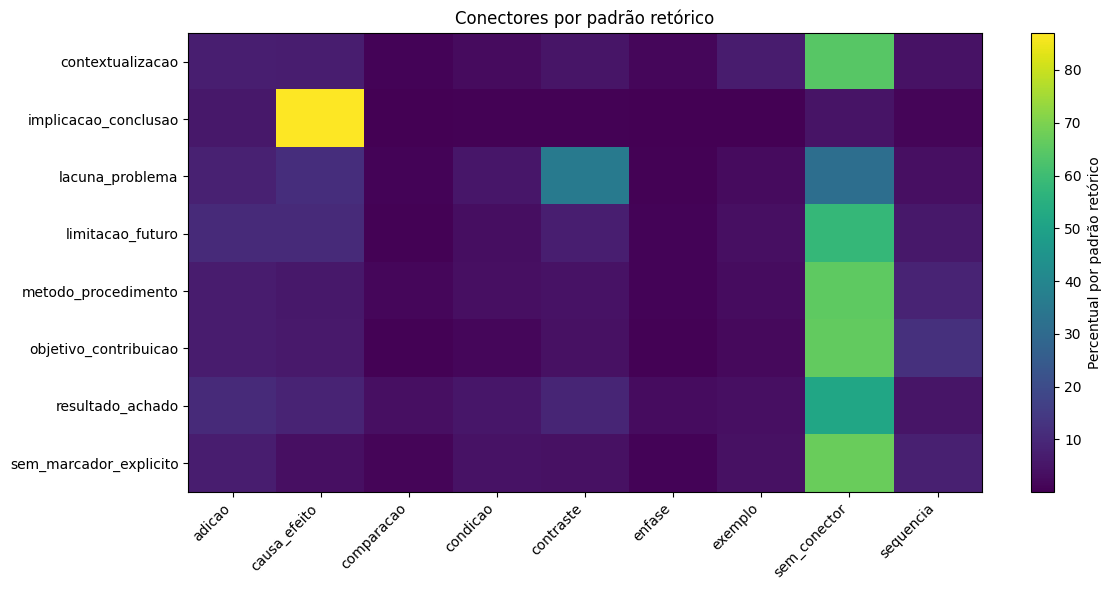

In [ ]:
tabela_retorica_conector = pd.crosstab(
    df_sent["padrao_retorico"],
    df_sent["conector_principal"],
    normalize="index"
) * 100

display(tabela_retorica_conector.round(2))

plt.figure(figsize=(12, 6))
plt.imshow(tabela_retorica_conector.values, aspect="auto")
plt.xticks(range(len(tabela_retorica_conector.columns)), tabela_retorica_conector.columns, rotation=45, ha="right")
plt.yticks(range(len(tabela_retorica_conector.index)), tabela_retorica_conector.index)
plt.colorbar(label="Percentual por padrão retórico")
plt.title("Conectores por padrão retórico")
plt.tight_layout()
plt.show()


## 7. Exemplos de sentenças por padrão retórico

In [ ]:
for padrao in resumo_padroes["padrao_retorico"].tolist():
    print("\n" + "=" * 100)
    print(padrao)
    exemplos = df_sent[df_sent["padrao_retorico"] == padrao].sample(
        min(5, (df_sent["padrao_retorico"] == padrao).sum()),
        random_state=RANDOM_STATE
    )
    for sent in exemplos["sentenca_modelo"].tolist():
        print("-", sent)



sem_marcador_explicito
- Red circles and yellow squares highlight local patches for better visualization. capability to vividly render and animate 3D data, point clouds have been employed as fundamental components to support immersive and realistic interactions, including Virtual Reality, Augmented Reality as well as Mixed Reality .
- The APG-G papers that we survey follow two main strategies for selecting music for the group playlist: deterministic and stochastic.
- It learns a node-level and a semantic-level attention,hierarchically.Thenembeddingsaregeneratedfornodesbyaggregatingfeaturesfrom metapath-basedneighbors.
- Such a target has to be identified from a set of nearby vehicles.
- I don t even really think about the fact that I m in a male-dominated profession.

metodo_procedimento
- To statistically test the effect of each of the metrics, recall and precision, and their interaction on the number of bugs detected by SBST-guided-by-DP, we conduct the two-way ANOVA test.
- 6 CONCL

## 8. Perfil geral de escrita por artigo

Aqui os padrões de sentença são agregados por artigo. Isso permite identificar perfis como textos com mais marcadores de método, textos mais argumentativos, textos com maior uso de contraste, textos com mais modalização etc.

In [ ]:
base_artigos = df_sent.groupby(COLUNA_ID).agg(
    n_sentencas=("sentenca_modelo", "count"),
    media_palavras_sentenca=("n_palavras", "mean"),
    mediana_palavras_sentenca=("n_palavras", "median"),
    conectores_por_sentenca=("n_conectores", "mean"),
    marcadores_retoricos_por_sentenca=("n_marcadores_retoricos", "mean"),
    perc_sentencas_com_citacao=("tem_citacao", "mean"),
    perc_primeira_pessoa=("tem_primeira_pessoa", "mean"),
    perc_modalizacao=("tem_modalizacao", "mean"),
    perc_voz_passiva_aprox=("voz_passiva_aprox", "mean")
).reset_index()

padroes_artigo = pd.crosstab(df_sent[COLUNA_ID], df_sent["padrao_retorico"], normalize="index") * 100
padroes_artigo.columns = [f"perc_ret_{c}" for c in padroes_artigo.columns]
padroes_artigo = padroes_artigo.reset_index()

conectores_artigo = df_sent.groupby(COLUNA_ID)[colunas_conectores].sum().reset_index()
for c in colunas_conectores:
    conectores_artigo[c] = 1000 * conectores_artigo[c] / base_artigos.set_index(COLUNA_ID).loc[conectores_artigo[COLUNA_ID], "n_sentencas"].values
conectores_artigo = conectores_artigo.rename(columns={c: c.replace("con_", "tx_con_") for c in colunas_conectores})

df_artigos = base_artigos.merge(padroes_artigo, on=COLUNA_ID, how="left").merge(conectores_artigo, on=COLUNA_ID, how="left")
df_artigos = df_artigos.fillna(0)

display(df_artigos.head())


,arquivo,n_sentencas,media_palavras_sentenca,mediana_palavras_sentenca,conectores_por_sentenca,marcadores_retoricos_por_sentenca,perc_sentencas_com_citacao,perc_primeira_pessoa,perc_modalizacao,perc_voz_passiva_aprox,perc_ret_contextualizacao,perc_ret_implicacao_conclusao,perc_ret_lacuna_problema,perc_ret_limitacao_futuro,perc_ret_metodo_procedimento,perc_ret_objetivo_contribuicao,perc_ret_resultado_achado,perc_ret_sem_marcador_explicito,tx_con_adicao,tx_con_contraste,tx_con_causa_efeito,tx_con_sequencia,tx_con_exemplo,tx_con_comparacao,tx_con_condicao,tx_con_enfase
0,/content/drive/MyDrive/ARTIGOS SELECIONADOS/1 - ACM Computing Surveys/DEZ_2024/3654662.pdf,318,22.710692,20.0,0.452830,0.433962,0.0,0.141509,0.106918,0.182390,1.886792,3.459119,11.949686,0.314465,11.635220,2.201258,3.773585,64.779874,69.182390,84.905660,59.748428,113.207547,84.905660,3.144654,18.867925,18.867925
1,/content/drive/MyDrive/ARTIGOS SELECIONADOS/1 - ACM Computing Surveys/DEZ_2024/3657281.pdf,483,18.821946,18.0,0.262940,0.463768,0.0,0.024845,0.053830,0.091097,0.000000,0.621118,10.766046,1.449275,16.977226,0.000000,4.968944,65.217391,64.182195,45.548654,24.844720,51.759834,45.548654,6.211180,8.281573,16.563147
2,/content/drive/MyDrive/ARTIGOS SELECIONADOS/1 - ACM Computing Surveys/DEZ_2024/3657632.pdf,346,22.416185,21.0,0.430636,0.312139,0.0,0.063584,0.130058,0.135838,1.734104,0.867052,8.381503,1.156069,4.624277,0.289017,5.780347,77.167630,104.046243,115.606936,28.901734,52.023121,86.705202,17.341040,11.560694,14.450867
3,/content/drive/MyDrive/ARTIGOS SELECIONADOS/1 - ACM Computing Surveys/DEZ_2024/3658666.pdf,360,23.063889,21.0,0.641667,0.263889,0.0,0.163889,0.202778,0.197222,0.277778,0.555556,4.722222,1.111111,9.444444,0.000000,6.111111,77.777778,113.888889,141.666667,33.333333,80.555556,127.777778,16.666667,55.555556,72.222222
4,/content/drive/MyDrive/ARTIGOS SELECIONADOS/1 - ACM Computing Surveys/DEZ_2024/3659576.pdf,457,18.326039,16.0,0.470460,0.247265,0.0,0.039387,0.201313,0.129103,0.437637,1.750547,11.378556,0.218818,3.719912,0.437637,3.719912,78.336980,76.586433,118.161926,48.140044,48.140044,65.645514,2.188184,105.032823,6.564551


## 9. Agrupamento de artigos por perfil de escrita

O clustering abaixo usa apenas características de escrita, não termos temáticos. A intenção é descobrir perfis gerais de escrita científica no corpus.

In [ ]:
feature_cols = [
    c for c in df_artigos.columns
    if c not in [COLUNA_ID] and pd.api.types.is_numeric_dtype(df_artigos[c])
]

X = df_artigos[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
X_scaled = StandardScaler().fit_transform(X)

resultados_k = []
limite_k = min(10, len(df_artigos) - 1)

for k in range(2, limite_k + 1):
    modelo = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = modelo.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    resultados_k.append({"k": k, "silhouette": sil})

resultados_k = pd.DataFrame(resultados_k)
display(resultados_k)

BEST_K = int(resultados_k.sort_values("silhouette", ascending=False).iloc[0]["k"])

modelo_final = KMeans(n_clusters=BEST_K, random_state=RANDOM_STATE, n_init=20)
df_artigos["cluster_estilo"] = modelo_final.fit_predict(X_scaled)

print("Melhor k:", BEST_K)
display(df_artigos["cluster_estilo"].value_counts().sort_index())


,k,silhouette
0,2,0.124393
1,3,0.093722
2,4,0.087680
3,5,0.082279
4,6,0.089874
5,7,0.063153
6,8,0.059106
7,9,0.055905
8,10,0.060300


Melhor k: 2


,count
cluster_estilo,
0,503
1,297


In [ ]:
perfil_clusters = df_artigos.groupby("cluster_estilo")[feature_cols].mean()
perfil_global = df_artigos[feature_cols].mean()

linhas = []
for cluster, row in perfil_clusters.iterrows():
    diffs = (row - perfil_global).sort_values(ascending=False)
    for recurso, diferenca in diffs.head(10).items():
        linhas.append({
            "cluster_estilo": cluster,
            "recurso_mais_caracteristico": recurso,
            "media_cluster": row[recurso],
            "media_global": perfil_global[recurso],
            "diferenca": diferenca
        })

resumo_clusters_estilo = pd.DataFrame(linhas)
display(resumo_clusters_estilo)


,cluster_estilo,recurso_mais_caracteristico,media_cluster,media_global,diferenca
0,0,perc_ret_metodo_procedimento,11.599472,10.251739,1.347733
1,0,perc_ret_objetivo_contribuicao,1.919253,1.622621,0.296632
2,0,perc_ret_sem_marcador_explicito,67.710757,67.604330,0.106427
3,0,perc_ret_resultado_achado,6.434059,6.399802,0.034258
4,0,perc_primeira_pessoa,0.223873,0.208734,0.015139
5,0,perc_sentencas_com_citacao,0.000000,0.000000,0.000000
6,0,marcadores_retoricos_por_sentenca,0.439426,0.441312,-0.001886
7,0,perc_voz_passiva_aprox,0.166986,0.178300,-0.011314
8,0,perc_modalizacao,0.111165,0.135675,-0.024511
9,0,perc_ret_contextualizacao,0.811812,0.866386,-0.054574


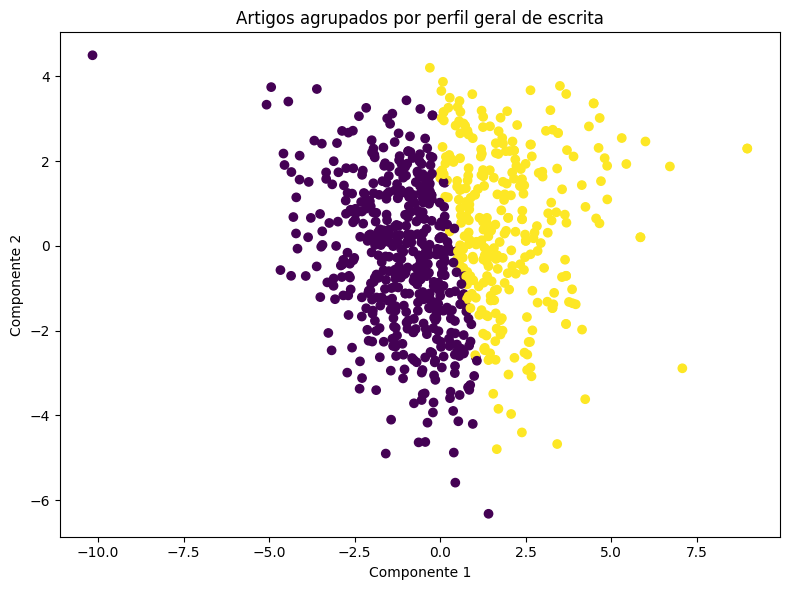

In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(coords[:, 0], coords[:, 1], c=df_artigos["cluster_estilo"])
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.title("Artigos agrupados por perfil geral de escrita")
plt.tight_layout()
plt.show()


## 10. Amostra para validação manual

Preencha a coluna `rotulo_humano` no arquivo exportado. Use preferencialmente os mesmos rótulos gerados pelo pipeline:

- contextualizacao
- lacuna_problema
- objetivo_contribuicao
- metodo_procedimento
- resultado_achado
- implicacao_conclusao
- limitacao_futuro
- sem_marcador_explicito

Depois de preencher, reexecute a célula de avaliação da validação manual.

In [ ]:
def gerar_amostra_validacao(df_sent, n_total=100):
    n_total = min(n_total, len(df_sent))
    partes = []
    for padrao, grupo in df_sent.groupby("padrao_retorico"):
        n = max(1, round(len(grupo) / len(df_sent) * n_total))
        partes.append(grupo.sample(min(n, len(grupo)), random_state=RANDOM_STATE))
    amostra = pd.concat(partes).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
    if len(amostra) > n_total:
        amostra = amostra.sample(n_total, random_state=RANDOM_STATE).reset_index(drop=True)
    return amostra

amostra_validacao = gerar_amostra_validacao(df_sent, n_total=100)
amostra_validacao = amostra_validacao[[
    COLUNA_ID,
    "ordem_sentenca",
    "sentenca_modelo",
    "padrao_retorico",
    "conector_principal",
    "n_marcadores_retoricos",
    "n_conectores"
]].copy()
amostra_validacao["rotulo_humano"] = ""
amostra_validacao["observacao"] = ""

CAMINHO_VALIDACAO = str(Path(SAIDA_DIR) / "amostra_validacao_manual.csv")
amostra_validacao.to_csv(CAMINHO_VALIDACAO, index=False)

print(CAMINHO_VALIDACAO)
display(amostra_validacao.head(10))


/content/drive/MyDrive/ARTIGOS SELECIONADOS/resultados_padroes_gerais_escrita/amostra_validacao_manual.csv


,arquivo,ordem_sentenca,sentenca_modelo,padrao_retorico,conector_principal,n_marcadores_retoricos,n_conectores,rotulo_humano,observacao
0,/content/drive/MyDrive/ARTIGOS SELECIONADOS/2- ACM Transactions on Computing Education/JUN_2023/3582275.pdf,204,This was conducted through initially contacting participants by identifying their publicly available contact email a...,sem_marcador_explicito,sem_conector,0,0,,
1,/content/drive/MyDrive/ARTIGOS SELECIONADOS/5 - ACM Transactions on Internet Technology/NOV_2023/3590963.pdf,108,All datasets are obtained from clean spectra by means of a model of degenerate spectra.,sem_marcador_explicito,sem_conector,0,0,,
2,/content/drive/MyDrive/ARTIGOS SELECIONADOS/1 - ACM Computing Surveys/NOV_2024/3666002.pdf,57,"Additionally, this study explores EEG-related physiological knowledge discovery, which significantly contributes to ...",sem_marcador_explicito,adicao,0,2,,
3,/content/drive/MyDrive/ARTIGOS SELECIONADOS/4 - ACM Transactions on Intelligent Systems and Technology/DEZ_2024/3696...,144,"Finally, the same script reshapes all the images based on the user s input threshold, thereby preparing the data for...",metodo_procedimento,sequencia,1,1,,
4,/content/drive/MyDrive/ARTIGOS SELECIONADOS/5 - ACM Transactions on Internet Technology/AGO_2023/3511898.pdf,108,"RBS2:AgainTAcomputes the temporal credentials of BSiasTCBSi h(IDBSi RTSBSi sBSi sTA),w h e r eRTSBSiis the registrat...",sem_marcador_explicito,sem_conector,0,0,,
5,/content/drive/MyDrive/ARTIGOS SELECIONADOS/3 - ACM Transactions on Graphics/DEZ_2024/3687757.pdf,9,The reconstruction results can be used for realistic re-rendering. Corresponding author: Lin Gao,sem_marcador_explicito,sem_conector,0,0,,
6,/content/drive/MyDrive/ARTIGOS SELECIONADOS/7 - ACM Transactions on Software Engineering and Methodology/JUN_2024/36...,129,Figure1showsthedefinitionofdifferenttypesof PythonannotationsbasedonPEP484describedinSection 2.1.Elementarytypesarec...,sem_marcador_explicito,exemplo,0,1,,
7,/content/drive/MyDrive/ARTIGOS SELECIONADOS/3 - ACM Transactions on Graphics/DEZ_2024/3687911.pdf,201,"As a result, the yarn-level deformation can be understood as a quasi-static one under the noninertia frame, and the ...",sem_marcador_explicito,causa_efeito,0,2,,
8,/content/drive/MyDrive/ARTIGOS SELECIONADOS/2- ACM Transactions on Computing Education/JUN_2024/3633464.pdf,272,"They argued that this is important to keep in mind, as CS courses have traditionally not been marketed to girls, par...",lacuna_problema,enfase,2,1,,
9,/content/drive/MyDrive/ARTIGOS SELECIONADOS/2- ACM Transactions on Computing Education/SET_2023/3686165.pdf,223,"Considering that Philanthropists are motivated by purpose, i.e., Philanthropists are people who are driven toward co...",contextualizacao,sem_conector,1,0,,


In [ ]:
validacao = pd.read_csv(CAMINHO_VALIDACAO)
validacao["rotulo_humano"] = validacao["rotulo_humano"].astype(str).str.strip()
validacao_preenchida = validacao[validacao["rotulo_humano"].ne("") & validacao["rotulo_humano"].ne("nan")].copy()

if len(validacao_preenchida) == 0:
    print("A validação manual ainda não foi preenchida.")
else:
    y_true = validacao_preenchida["rotulo_humano"]
    y_pred = validacao_preenchida["padrao_retorico"]
    print("Sentenças validadas:", len(validacao_preenchida))
    print("Acurácia:", accuracy_score(y_true, y_pred))
    print("Kappa:", cohen_kappa_score(y_true, y_pred))
    print(classification_report(y_true, y_pred, zero_division=0))
    display(pd.DataFrame(confusion_matrix(y_true, y_pred, labels=sorted(set(y_true) | set(y_pred))), index=sorted(set(y_true) | set(y_pred)), columns=sorted(set(y_true) | set(y_pred))))


A validação manual ainda não foi preenchida.


## 11. Exportação dos resultados

In [ ]:
caminhos_saida = {
    "sentencas_padroes_gerais": Path(SAIDA_DIR) / "sentencas_padroes_gerais.csv",
    "resumo_padroes_retoricos": Path(SAIDA_DIR) / "resumo_padroes_retoricos.csv",
    "ranking_conectores": Path(SAIDA_DIR) / "ranking_conectores.csv",
    "tabela_retorica_conector": Path(SAIDA_DIR) / "tabela_retorica_conector.csv",
    "perfil_artigos_escrita": Path(SAIDA_DIR) / "perfil_artigos_escrita.csv",
    "resumo_clusters_estilo": Path(SAIDA_DIR) / "resumo_clusters_estilo.csv"
}

df_sent.to_csv(caminhos_saida["sentencas_padroes_gerais"], index=False)
resumo_padroes.to_csv(caminhos_saida["resumo_padroes_retoricos"], index=False)
ranking_conectores.to_csv(caminhos_saida["ranking_conectores"], index=False)
tabela_retorica_conector.to_csv(caminhos_saida["tabela_retorica_conector"])
df_artigos.to_csv(caminhos_saida["perfil_artigos_escrita"], index=False)
resumo_clusters_estilo.to_csv(caminhos_saida["resumo_clusters_estilo"], index=False)

for nome, caminho in caminhos_saida.items():
    print(nome, "->", caminho)


sentencas_padroes_gerais -> /content/drive/MyDrive/ARTIGOS SELECIONADOS/resultados_padroes_gerais_escrita/sentencas_padroes_gerais.csv
resumo_padroes_retoricos -> /content/drive/MyDrive/ARTIGOS SELECIONADOS/resultados_padroes_gerais_escrita/resumo_padroes_retoricos.csv
ranking_conectores -> /content/drive/MyDrive/ARTIGOS SELECIONADOS/resultados_padroes_gerais_escrita/ranking_conectores.csv
tabela_retorica_conector -> /content/drive/MyDrive/ARTIGOS SELECIONADOS/resultados_padroes_gerais_escrita/tabela_retorica_conector.csv
perfil_artigos_escrita -> /content/drive/MyDrive/ARTIGOS SELECIONADOS/resultados_padroes_gerais_escrita/perfil_artigos_escrita.csv
resumo_clusters_estilo -> /content/drive/MyDrive/ARTIGOS SELECIONADOS/resultados_padroes_gerais_escrita/resumo_clusters_estilo.csv


## 12. Síntese automática para relatório

In [ ]:
principais_padroes = resumo_padroes.head(5).copy()
principais_conectores = ranking_conectores.head(5).copy()

linhas = []
linhas.append("# Síntese dos padrões gerais de escrita científica")
linhas.append("")
linhas.append(f"Foram analisados {len(df)} artigos e {len(df_sent)} sentenças válidas extraídas do texto completo.")
linhas.append("")
linhas.append("## Padrões retóricos mais frequentes")
for _, row in principais_padroes.iterrows():
    linhas.append(f"- {row['padrao_retorico']}: {row['percentual']:.2f}% das sentenças")
linhas.append("")
linhas.append("## Conectores mais frequentes")
for _, row in principais_conectores.iterrows():
    linhas.append(f"- {row['tipo_conector']}: {row['por_1000_sentencas']:.2f} ocorrências por 1000 sentenças")
linhas.append("")
linhas.append("## Agrupamento por perfil de escrita")
linhas.append(f"O melhor número de clusters foi k={BEST_K}, escolhido por silhouette sobre características de escrita agregadas por artigo.")
linhas.append("")
linhas.append("## Interpretação metodológica")
linhas.append("Este pipeline prioriza padrões de escrita identificáveis no texto completo, como movimentos retóricos, conectores, modalização, citações, primeira pessoa e uso aproximado de voz passiva. O clustering é usado apenas para agrupar artigos por perfil de escrita, e não para inferir padrões retóricos diretamente.")

CAMINHO_RELATORIO = Path(SAIDA_DIR) / "sintese_padroes_gerais.md"
CAMINHO_RELATORIO.write_text("\n".join(linhas), encoding="utf-8")

print(CAMINHO_RELATORIO)
print("\n".join(linhas))


/content/drive/MyDrive/ARTIGOS SELECIONADOS/resultados_padroes_gerais_escrita/sintese_padroes_gerais.md
# Síntese dos padrões gerais de escrita científica

Foram analisados 800 artigos e 232355 sentenças válidas extraídas do texto completo.

## Padrões retóricos mais frequentes
- sem_marcador_explicito: 68.13% das sentenças
- metodo_procedimento: 10.24% das sentenças
- lacuna_problema: 9.27% das sentenças
- resultado_achado: 6.37% das sentenças
- implicacao_conclusao: 3.07% das sentenças

## Conectores mais frequentes
- contraste: 105.57 ocorrências por 1000 sentenças
- sequencia: 103.72 ocorrências por 1000 sentenças
- causa_efeito: 87.21 ocorrências por 1000 sentenças
- adicao: 82.46 ocorrências por 1000 sentenças
- condicao: 57.88 ocorrências por 1000 sentenças

## Agrupamento por perfil de escrita
O melhor número de clusters foi k=2, escolhido por silhouette sobre características de escrita agregadas por artigo.

## Interpretação metodológica
Este pipeline prioriza padrões de escri